In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs:int
    balls: int
    fours : int
    sixes: int
    
    strike_rate : float
    balls_per_boundary: float
    boundary_percent:float
    
    summary : str

In [11]:
def calculate_sr(state:BatsmanState):
    sr = (state['runs']/state['balls'])*100
    return {'strike_rate': sr}

def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours']+ state['sixes'])
    return {'balls_per_boundary': bpb}

def calculate_bp(state: BatsmanState):
    bp = (((state['fours']*4) + (state['sixes']*6))/ state['runs'])*100
    return {'boundary_percent': bp}
     
def summary(state: BatsmanState):
    summary = f"""
                Strike Rate: {state['strike_rate']}\n
                Balls per boundary : {state['balls_per_boundary']}\n
                Boundary percent : {state['boundary_percent']}
            """
    return {'summary': summary}
    

In [7]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strikerate', calculate_sr)
graph.add_node('calculate_balls_per_boundary', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_bp)
graph.add_node('summary', summary)

#edges
graph.add_edge(START,'calculate_strikerate')
graph.add_edge(START,'calculate_balls_per_boundary')
graph.add_edge(START,'calculate_boundary_percent',)

graph.add_edge('calculate_strikerate','summary')
graph.add_edge('calculate_boundary_percent','summary')
graph.add_edge('calculate_balls_per_boundary','summary')

graph.add_edge('summary',END)

workflow = graph.compile()

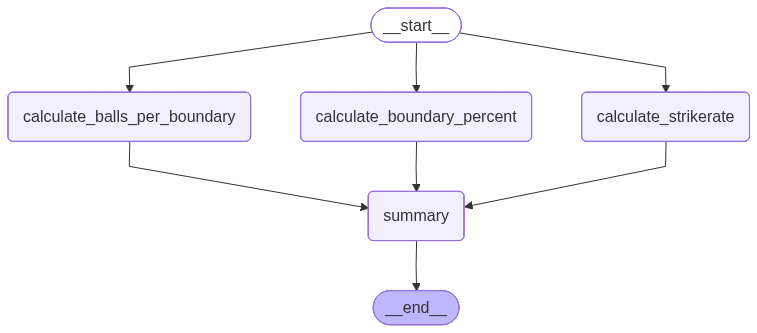

In [5]:
workflow

In [12]:
initial_state = {
    'runs':100,
    'balls':50,
    'fours':7,
    'sixes': 3
        }

final_state = workflow.invoke(initial_state)

In [14]:
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 7, 'sixes': 3, 'strike_rate': 0.02, 'balls_per_boundary': 5.0, 'boundary_percent': 46.0, 'summary': '\n                Strike Rate: 0.02\n\n                Balls per boundary : 5.0\n\n                Boundary percent : 46.0\n            '}
